## Data Analysis

This chapter provides a comprehensive exploratory data analysis of the vehicle registration dataset. The analysis examines the temporal structure, statistical properties, and relationships within the data to inform the subsequent modeling approach.

The analysis is structured into several key sections: descriptive statistics and distribution patterns across vehicle types and manufacturers, static correlation analysis to identify relationships between numeric features, time trend visualization to reveal long-term patterns and seasonal effects, autocorrelation analysis to quantify temporal dependencies within individual series, and cross-correlation analysis to assess lagged relationships between exogenous variables and registration volumes.

Understanding these characteristics is essential for designing effective neural network architectures, selecting appropriate input features, and determining suitable sequence lengths for time series forecasting models.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import ccf
import numpy as np
import math as math

### Data Understanding

For the explorative data analysis the final processed dataset monthly_registration_volume_gold.parquet with all relevant features was used.

In [36]:
storage_path = "../data/gold/monthly_registration_volume_gold.parquet"
df = pd.read_parquet(storage_path, engine='pyarrow')
df.head()

,ts_key,Date,Value,Employment_Level,Employment_Level_Change,Employment_Level_Relative_Change,Employment_Level_YoY_Change,Employment_Level_YoY_Relative_Change,Employment_Level_MA_3,Employment_Level_MA_6,consumer_price_index,YoY_change,MoM_change,Deposit_Rate,Deposit_Rate_Change,Deposit_Rate_Relative_Change,Deposit_Rate_YoY_Change,GDP,Lending_Rate,Lending_Rate_Change,Lending_Rate_Relative_Change,Lending_Rate_YoY_Change,Lending_Rate_YoY_Relative_Change,GR_price_with_tax_euro95,GR_price_with_tax_diesel,GR_price_with_tax_heGRing_oil,GR_price_with_tax_fuel_oil_1,OEM,Model,drive_type,Year,Month
0,ALFA ROMEO_GIULIA_All_Wheel_Drive,2018-01-31,54.0,32504413,-104455.0,-0.00320,796982.0,0.02514,3.264763e+07,3.264138e+07,96.4,1.4,0.0031,-0.4,0.0,0.0,0.0,104.34,0.25,0.0,0.0,0.0,0.0,1550.0,1326.0,1018.0,442.14,ALFA ROMEO,GIULIA,All_Wheel_Drive,2018,1
1,ALFA ROMEO_GIULIA_All_Wheel_Drive,2018-02-28,23.0,32550748,46335.0,0.00143,776950.0,0.02445,3.255468e+07,3.266715e+07,96.7,1.2,0.0031,-0.4,0.0,0.0,0.0,104.34,0.25,0.0,0.0,0.0,0.0,1550.0,1325.0,1010.0,424.16,ALFA ROMEO,GIULIA,All_Wheel_Drive,2018,2
2,ALFA ROMEO_GIULIA_All_Wheel_Drive,2018-03-31,85.0,32660492,109744.0,0.00337,730269.0,0.02287,3.257188e+07,3.265527e+07,97.2,1.5,0.0052,-0.4,0.0,0.0,0.0,102.81,0.25,0.0,0.0,0.0,0.0,1533.0,1309.0,991.0,431.53,ALFA ROMEO,GIULIA,All_Wheel_Drive,2018,3
3,ALFA ROMEO_GIULIA_All_Wheel_Drive,2018-04-30,51.0,32782173,121681.0,0.00373,768929.0,0.02402,3.266447e+07,3.265605e+07,97.5,1.4,0.0031,-0.4,0.0,0.0,0.0,102.81,0.25,0.0,0.0,0.0,0.0,1575.0,1348.0,1025.0,453.57,ALFA ROMEO,GIULIA,All_Wheel_Drive,2018,4
4,ALFA ROMEO_GIULIA_All_Wheel_Drive,2018-05-31,77.0,32857311,75138.0,0.00229,725968.0,0.02259,3.276666e+07,3.266067e+07,98.2,2.1,0.0072,-0.4,0.0,0.0,0.0,102.81,0.25,0.0,0.0,0.0,0.0,1647.0,1420.0,1025.0,520.12,ALFA ROMEO,GIULIA,All_Wheel_Drive,2018,5


As already described in the section Data Description the dataset consists of the KBA registration data and exogenous variables.
KBA registration data are describing the registrations of vehicles in Germany including the vehicle model, the timepoint and the number of registrations per month and are shown in the following dataset:



In [37]:
#copy dataframe and remove all columns besides ts_key, value, Date, OEM, drive_type, Month, Year
df_kba = df[['ts_key', 'Value', 'Date', 'OEM', 'drive_type', 'Model', 'Month', 'Year']].copy()
df_kba.head()


,ts_key,Value,Date,OEM,drive_type,Model,Month,Year
0,ALFA ROMEO_GIULIA_All_Wheel_Drive,54.0,2018-01-31,ALFA ROMEO,All_Wheel_Drive,GIULIA,1,2018
1,ALFA ROMEO_GIULIA_All_Wheel_Drive,23.0,2018-02-28,ALFA ROMEO,All_Wheel_Drive,GIULIA,2,2018
2,ALFA ROMEO_GIULIA_All_Wheel_Drive,85.0,2018-03-31,ALFA ROMEO,All_Wheel_Drive,GIULIA,3,2018
3,ALFA ROMEO_GIULIA_All_Wheel_Drive,51.0,2018-04-30,ALFA ROMEO,All_Wheel_Drive,GIULIA,4,2018
4,ALFA ROMEO_GIULIA_All_Wheel_Drive,77.0,2018-05-31,ALFA ROMEO,All_Wheel_Drive,GIULIA,5,2018


Idd addition to the KBA registration data exogenous data, which are mainly economic data were included into the dataset. These variables are listed in the following:

In [40]:
df_exogenous = df.drop(columns=['ts_key', 'Value', 'Date', 'OEM', 'drive_type', 'Model', 'Month', 'Year']).copy()
df_exogenous.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107917 entries, 0 to 107916
Data columns (total 24 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Employment_Level                      107917 non-null  int64  
 1   Employment_Level_Change               107917 non-null  float64
 2   Employment_Level_Relative_Change      107917 non-null  float64
 3   Employment_Level_YoY_Change           107917 non-null  float64
 4   Employment_Level_YoY_Relative_Change  107917 non-null  float64
 5   Employment_Level_MA_3                 107917 non-null  float64
 6   Employment_Level_MA_6                 107917 non-null  float64
 7   consumer_price_index                  107917 non-null  float64
 8   YoY_change                            107917 non-null  float64
 9   MoM_change                            107917 non-null  float64
 10  Deposit_Rate                          107917 non-null  float64
 11  

In [21]:
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns in the dataset.")
print(f"There are {df['ts_key'].nunique()} unique time series in the dataset.")

There are 107917 rows and 32 columns in the dataset.
There are 1502 unique time series in the dataset.


In [27]:
#show summary statistics of Value column
df['Value'].describe()

count    107917.000000
mean        432.691847
std         874.739536
min           0.000000
25%           4.000000
50%          88.000000
75%         459.000000
max       22335.000000
Name: Value, dtype: float64

### Univariate Analysis

In the following section, the distribution of vehicle registrations across different categorical variables is examined. This analysis focuses on understanding how registration volumes are distributed among various vehicle types (drive types) and manufacturers (OEMs). By aggregating total registrations for each category, we can identify which segments dominate the market and reveal potential imbalances in the dataset that may influence model performance. These insights help determine whether certain categories require special attention during modeling, such as stratified sampling or category-specific models.

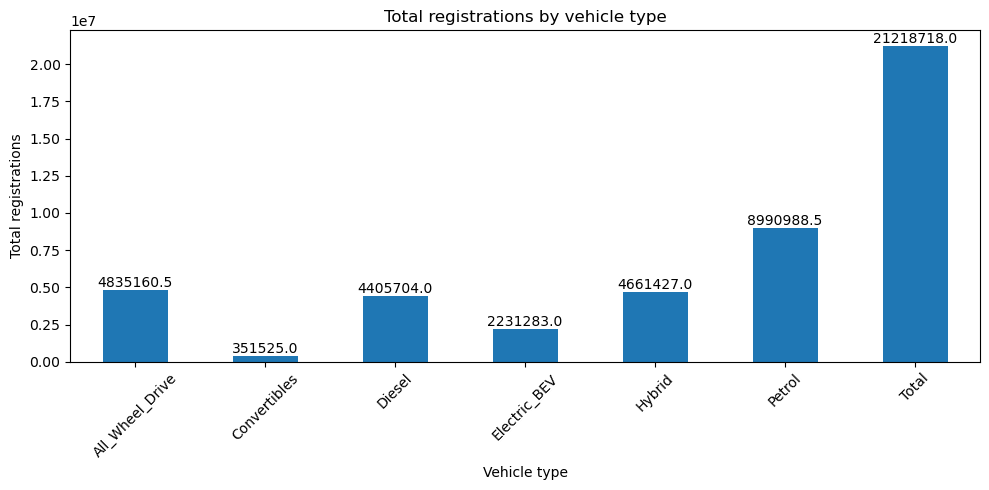

In [ ]:
sum_by_type = df.groupby("drive_type")["Value"].sum()

plt.figure(figsize=(10, 5))
sum_by_type.plot(kind="bar")
plt.ylabel("Total registrations")
plt.xlabel("Vehicle type")
plt.title("Total registrations by vehicle type")
plt.xticks(rotation=45)
#add labels on top of the bars
for i, v in enumerate(sum_by_type):
    plt.text(i, v + 1000, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

The distribution of vehicle registrations across drive types reveals substantial class imbalance in the dataset. Petrol vehicles dominate with approximately 8.99 million registrations across the observation period, while convertibles represent the smallest segment with only 352,000 registrations—a difference of more than 25-fold. This significant imbalance has important implications for model training, as neural networks may exhibit bias toward predicting well-represented classes. 

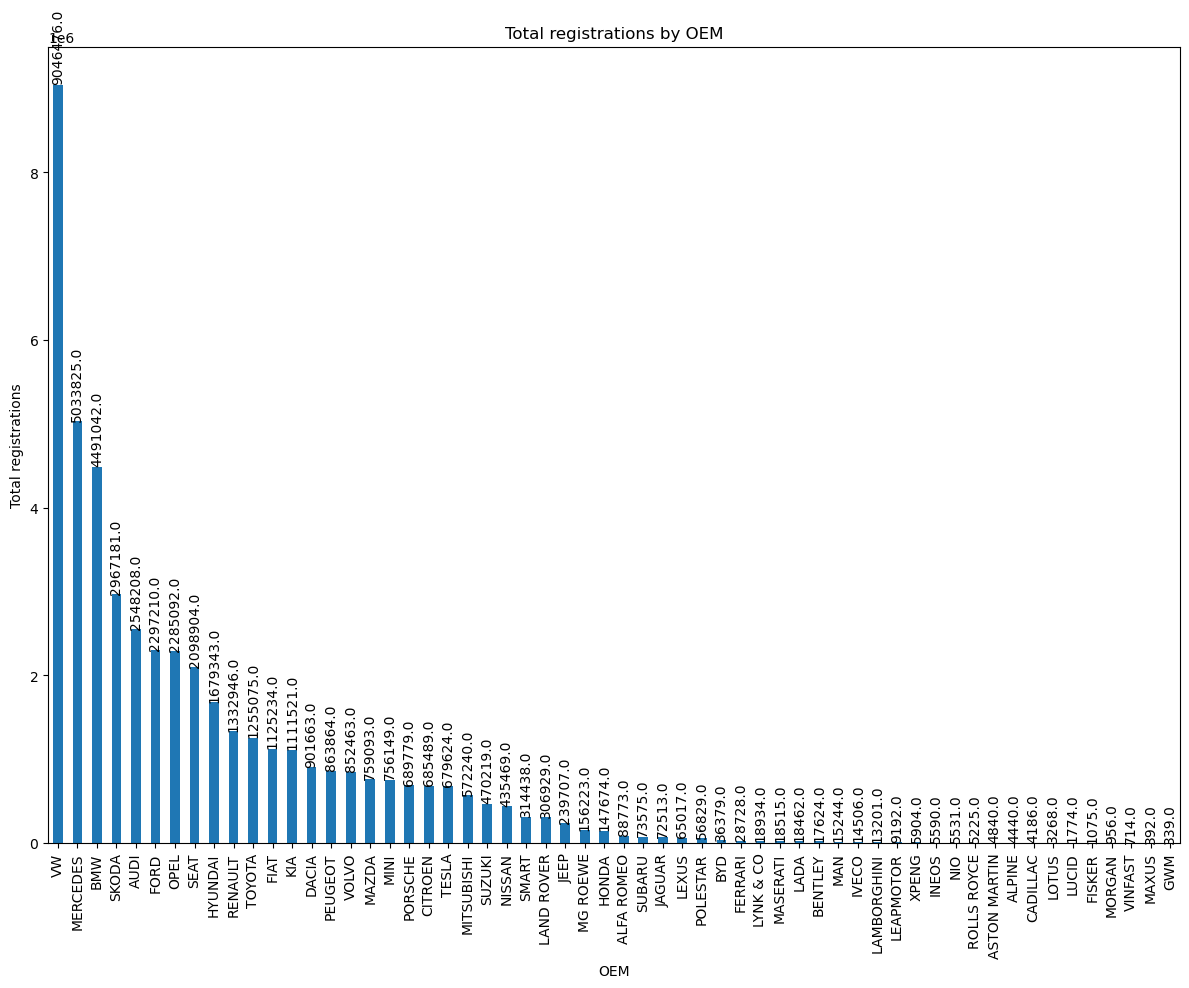

In [58]:
sum_by_oem = df.groupby("OEM")["Value"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 10))
sum_by_oem.plot(kind="bar")
plt.ylabel("Total registrations")
plt.xlabel("OEM")
plt.title("Total registrations by OEM")
plt.xticks(rotation=90)
#add labels on top of the bars
for i, v in enumerate(sum_by_oem):
    plt.text(i, v + 1000, str(v), ha='center', va='bottom', rotation=90)
plt.tight_layout()
plt.show()

A similar imbalance exists in the distribution of registrations across manufacturers (OEMs). Volkswagen (VW) dominates the market with approximately 9.0 million total registrations throughout the observation period, while GWM represents the opposite extreme with only 339 registered vehicles. The bar chart reveals that several OEMs have fewer than 10,000 total registrations, highlighting extreme variability in manufacturer representation. 

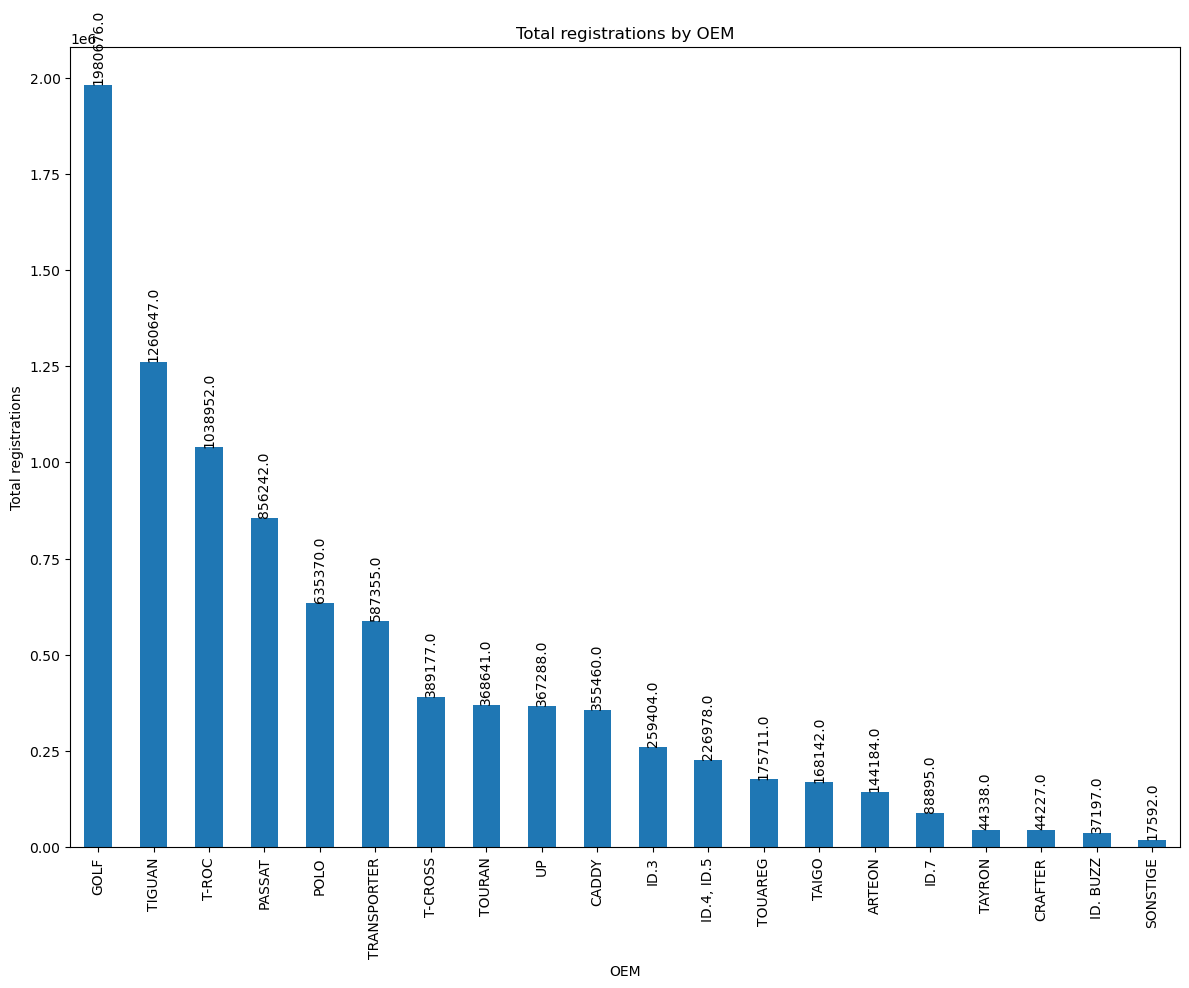

In [69]:
sum_by_model = df[df["OEM"] == "VW"].groupby("Model")["Value"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 10))
sum_by_model.plot(kind="bar")
plt.ylabel("Total registrations")
plt.xlabel("OEM")
plt.title("Total registrations by OEM")
plt.xticks(rotation=90)
#add labels on top of the bars
for i, v in enumerate(sum_by_model):
    plt.text(i, v + 1000, str(v), ha='center', va='bottom', rotation = 90)
plt.tight_layout()
plt.show()

To understand the distribution of registration volumes across individual vehicle models within a manufacturer, the chart above displays all VW models and their respective registration totals. Substantial variation exists between different models within the VW portfolio, mirroring the imbalance observed at the OEM level. 
Low-volume models present particular challenges for forecasting, as insufficient sample sizes lead to high volatility in monthly registration numbers, making reliable predictions extremely difficult. 

### Static Correlation

Static correlation analysis examines the linear relationships between numeric features in the dataset, regardless of their temporal structure. This analysis is essential for understanding how exogenous variables relate to vehicle registration volumes and to each other, helping to identify potential multicollinearity issues and inform feature selection for the forecasting models.

The following analysis presents correlation patterns at three levels of granularity: first, an overall correlation matrix across all time series to reveal general relationships; second, correlations segmented by vehicle type to account for differences in how economic factors affect different powertrains; and third, correlations for individual OEMs to capture manufacturer-specific sensitivities to external variables. These insights help determine which exogenous features are most relevant for different segments of the forecasting task.

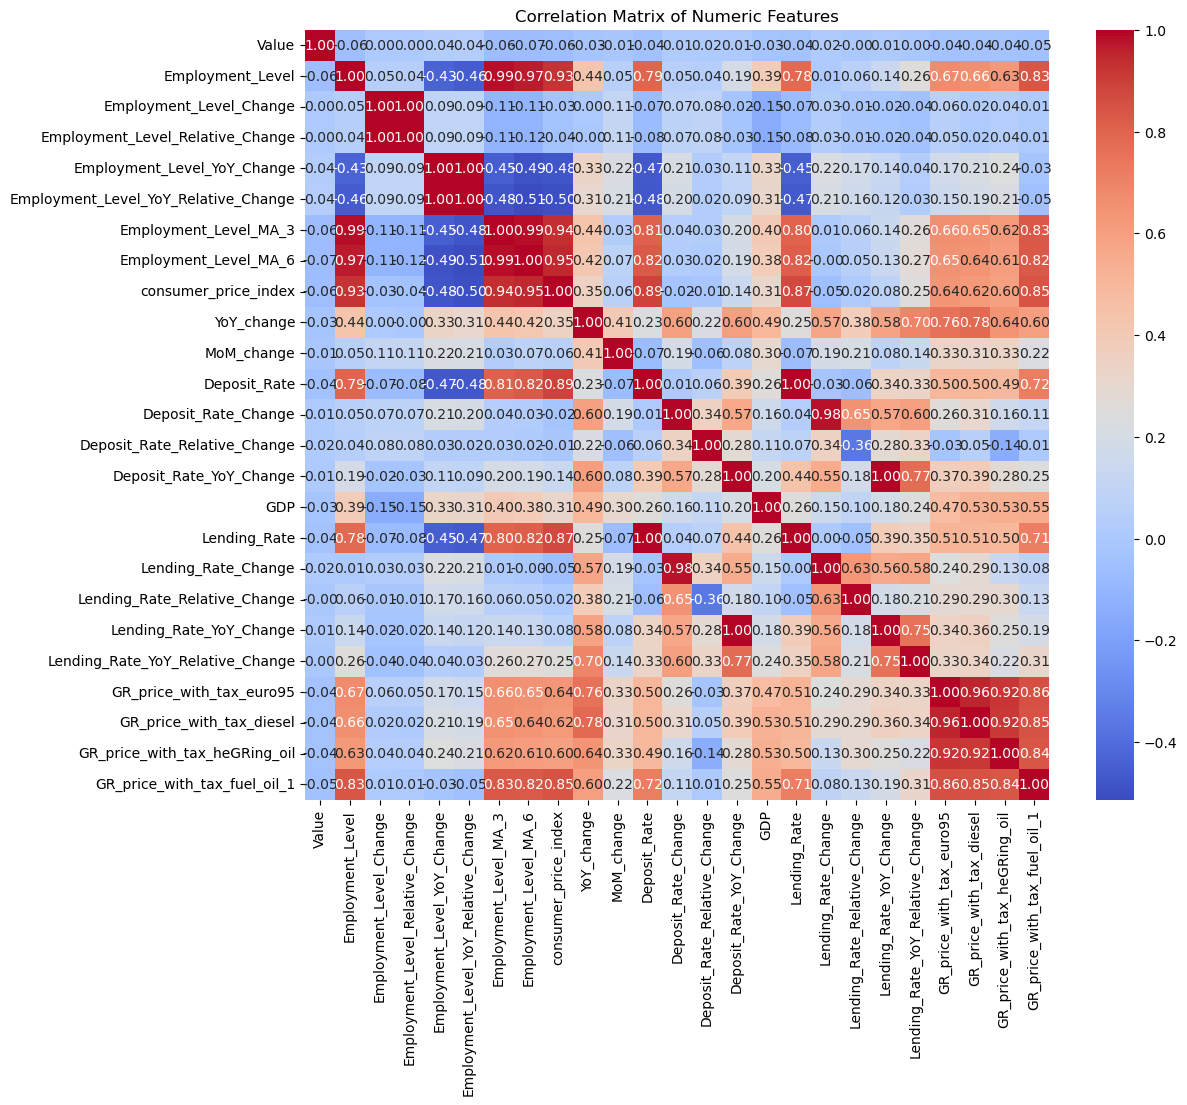

In [26]:
# build dataframe with all numeric columns only and exclude Month and Year
numeric_df = df.select_dtypes(include=['number']).drop(columns=['Month', 'Year'])   

# show correlation matrix of numeric columns
plt.figure(figsize=(12,10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [497]:

types = df['type'].unique().tolist()
num_cols = df.select_dtypes(include="number").columns

corr_list = []
for t in types:
    corr_t = (
        df[df["type"] == t][num_cols]
        .corr()["Value"]
        .drop("Value")
        .rename(t)
    )
    corr_list.append(corr_t)

corr_table = pd.concat(corr_list, axis=1).round(2)

styled = (
    corr_table
    .style
    .background_gradient(
        cmap="RdBu_r",   # rot = negativ, blau = positiv
        axis=None,
        vmin=-1, vmax=1
    )

)

styled


,All_Wheel_Drive,Diesel,Petrol,Total,BEV,Hybrid,Convertibles
Employment_Level,-0.050000,-0.170000,-0.170000,-0.110000,0.140000,0.230000,-0.100000
Employment_Level_Change,-0.000000,-0.000000,0.010000,0.000000,-0.010000,-0.010000,0.020000
Employment_Level_Relative_Change,-0.000000,0.000000,0.010000,0.000000,-0.010000,-0.010000,0.020000
Employment_Level_YoY_Change,0.040000,0.080000,0.100000,0.060000,-0.050000,-0.150000,0.040000
Employment_Level_YoY_Relative_Change,0.040000,0.090000,0.100000,0.060000,-0.060000,-0.160000,0.050000
Employment_Level_MA_3,-0.050000,-0.170000,-0.180000,-0.110000,0.140000,0.230000,-0.100000
Employment_Level_MA_6,-0.050000,-0.170000,-0.180000,-0.110000,0.140000,0.230000,-0.090000
consumer_price_index,-0.050000,-0.160000,-0.160000,-0.100000,0.120000,0.220000,-0.070000
YoY_change,-0.010000,-0.090000,-0.090000,-0.050000,0.140000,0.100000,-0.010000
MoM_change,-0.010000,-0.030000,-0.030000,-0.020000,0.010000,0.020000,0.030000


In [50]:
oems_top20 = (
    df.groupby("OEM")["Value"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

In [51]:
num_cols = df.select_dtypes(include="number").columns

corr_list = []
for t in oems_top20:
    corr_t = (
        df[df["OEM"] == t][num_cols]
        .corr()["Value"]
        .drop("Value")
        .rename(t)
    )
    corr_list.append(corr_t)

corr_table = pd.concat(corr_list, axis=1).round(2)

styled = (corr_table.style.background_gradient(cmap="RdBu", vmin=-1, vmax=1))

styled

,VW,MERCEDES,BMW,SKODA,AUDI,FORD,OPEL,SEAT,HYUNDAI,RENAULT,TOYOTA,FIAT,KIA,DACIA,PEUGEOT,VOLVO,MAZDA,MINI,PORSCHE,CITROEN
Employment_Level,-0.110000,-0.040000,-0.020000,-0.040000,0.070000,-0.190000,-0.040000,-0.060000,-0.230000,-0.180000,-0.040000,-0.120000,0.010000,-0.020000,-0.050000,0.070000,-0.130000,-0.090000,-0.000000,-0.030000
Employment_Level_Change,-0.010000,-0.000000,-0.010000,-0.010000,-0.010000,0.020000,0.020000,0.020000,0.040000,-0.010000,0.020000,0.030000,0.030000,-0.060000,-0.000000,-0.100000,0.050000,0.030000,-0.020000,0.020000
Employment_Level_Relative_Change,-0.010000,-0.000000,-0.010000,-0.000000,-0.010000,0.020000,0.020000,0.020000,0.040000,-0.000000,0.020000,0.030000,0.030000,-0.060000,-0.000000,-0.100000,0.050000,0.030000,-0.020000,0.020000
Employment_Level_YoY_Change,0.050000,0.010000,-0.000000,-0.030000,-0.030000,0.100000,0.030000,-0.010000,0.150000,0.070000,0.020000,0.050000,0.020000,0.040000,0.020000,-0.130000,0.090000,0.050000,0.020000,0.000000
Employment_Level_YoY_Relative_Change,0.050000,0.010000,0.000000,-0.030000,-0.030000,0.110000,0.030000,-0.000000,0.150000,0.080000,0.020000,0.050000,0.020000,0.040000,0.020000,-0.130000,0.100000,0.050000,0.020000,0.010000
Employment_Level_MA_3,-0.110000,-0.040000,-0.020000,-0.040000,0.070000,-0.190000,-0.050000,-0.070000,-0.230000,-0.180000,-0.040000,-0.120000,0.000000,-0.010000,-0.050000,0.080000,-0.140000,-0.100000,0.000000,-0.030000
Employment_Level_MA_6,-0.110000,-0.040000,-0.020000,-0.040000,0.080000,-0.200000,-0.050000,-0.060000,-0.240000,-0.200000,-0.040000,-0.120000,-0.000000,-0.010000,-0.050000,0.080000,-0.150000,-0.100000,0.000000,-0.020000
consumer_price_index,-0.090000,-0.030000,-0.010000,-0.010000,0.090000,-0.180000,-0.050000,-0.030000,-0.250000,-0.200000,-0.030000,-0.130000,-0.010000,0.010000,-0.040000,0.060000,-0.120000,-0.100000,0.020000,0.010000
YoY_change,-0.060000,-0.030000,-0.040000,-0.110000,0.050000,-0.090000,0.000000,-0.100000,-0.060000,-0.080000,-0.030000,-0.000000,0.050000,0.020000,-0.070000,-0.070000,-0.080000,-0.030000,0.010000,-0.050000
MoM_change,-0.030000,-0.030000,-0.040000,-0.050000,-0.010000,-0.040000,-0.010000,-0.050000,-0.020000,-0.050000,-0.010000,0.020000,-0.010000,-0.030000,-0.040000,-0.060000,-0.020000,-0.030000,0.030000,-0.000000


### Time Trend Analysis

Time trend analysis visualizes the temporal evolution of vehicle registration patterns to identify long-term trends, structural breaks, seasonal patterns, and heterogeneity across different segments. Unlike static correlation, this analysis explicitly considers the time dimension to reveal how registration volumes change over the observation period.

This section employs overlay plots to visualize multiple time series simultaneously with high transparency, allowing global patterns to emerge while maintaining visibility of individual series variability. The analysis is conducted at multiple aggregation levels: first, an overall view of all time series to identify dataset-wide trends; second, segmented by vehicle type to reveal powertrain-specific patterns influenced by technological shifts and policy changes; and third, segmented by manufacturer to capture brand-specific market dynamics.

Understanding these temporal patterns is crucial for neural network design, particularly for determining appropriate lookback windows, identifying the need for trend and seasonal components, and recognizing periods of structural change that may require special handling during model training and validation.

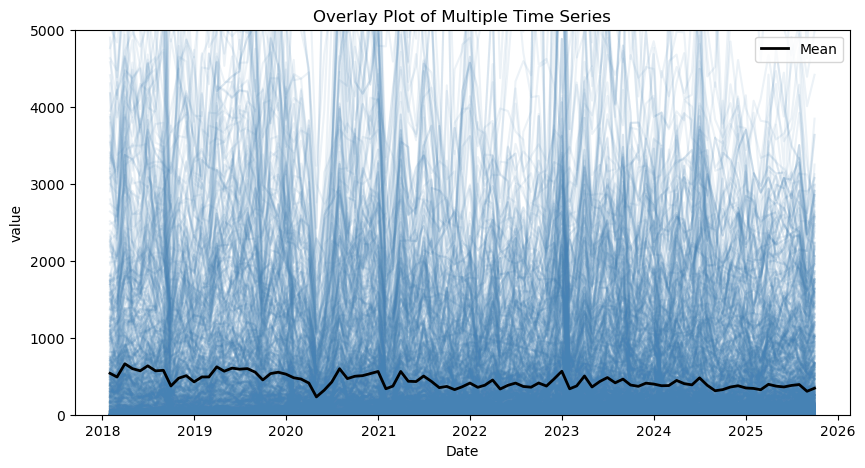

In [502]:
plt.figure(figsize=(10, 5))

for ts_key, g in df.groupby("ts_key"):
    plt.plot(g["Date"], g["Value"], alpha=0.1, color="steelblue")

plt.title("Overlay Plot of Multiple Time Series")
plt.xlabel("Date")
plt.ylabel("value")

mean_series = df.groupby("Date")["Value"].mean()
plt.plot(mean_series.index, mean_series, color="black", linewidth=2, label="Mean")
plt.legend()

# set y-axis scale to a maximum of 5000
plt.ylim(0, 5000)

plt.show()

An overlay plot was used to visualize the temporal structure of a large number of time series. Each series was plotted with high transparency to reveal global trends and heterogeneity across the dataset.


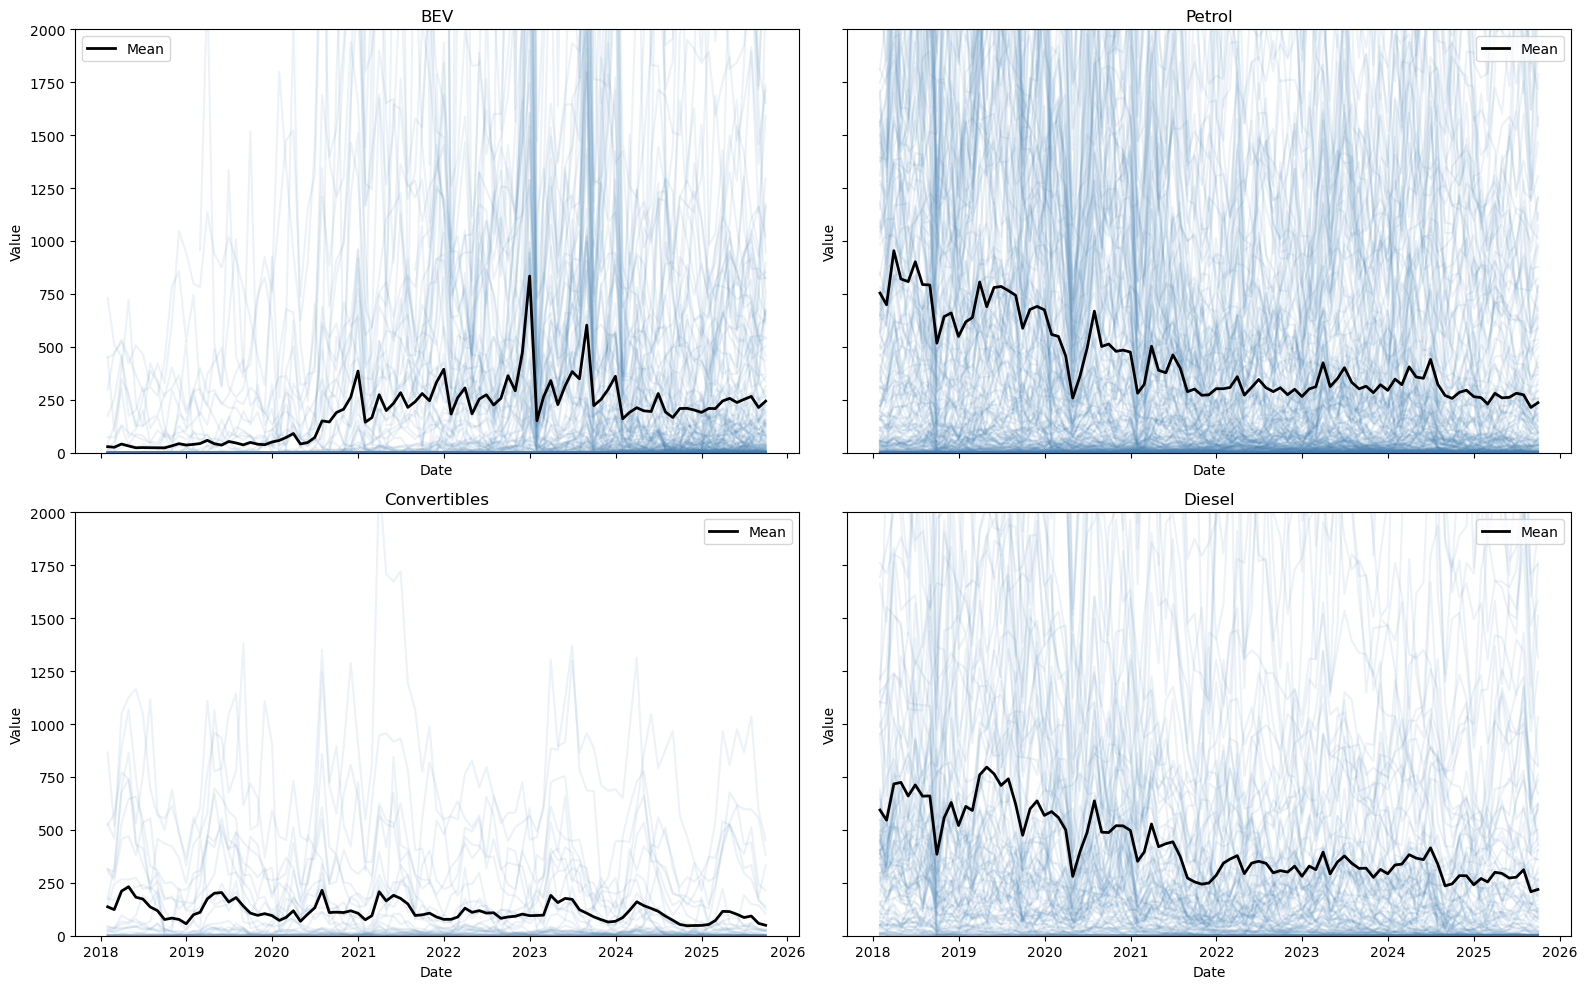

In [503]:
import matplotlib.pyplot as plt

vehicle_types = ["BEV", "Petrol", "Convertibles", "Diesel"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, v_type in zip(axes, vehicle_types):
    type_df = df[df["type"] == v_type].copy()
    type_df = type_df.sort_values("Date")

    # Overlay aller Zeitreihen
    for _, g in type_df.groupby("ts_key"):
        ax.plot(g["Date"], g["Value"], alpha=0.1, color="steelblue")

    # Mittelwert
    mean_series = type_df.groupby("Date")["Value"].mean()
    ax.plot(mean_series.index, mean_series, color="black", linewidth=2, label="Mean")

    ax.set_title(f"{v_type}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.set_ylim(0, 2000)
    ax.legend()

plt.tight_layout()
plt.show()


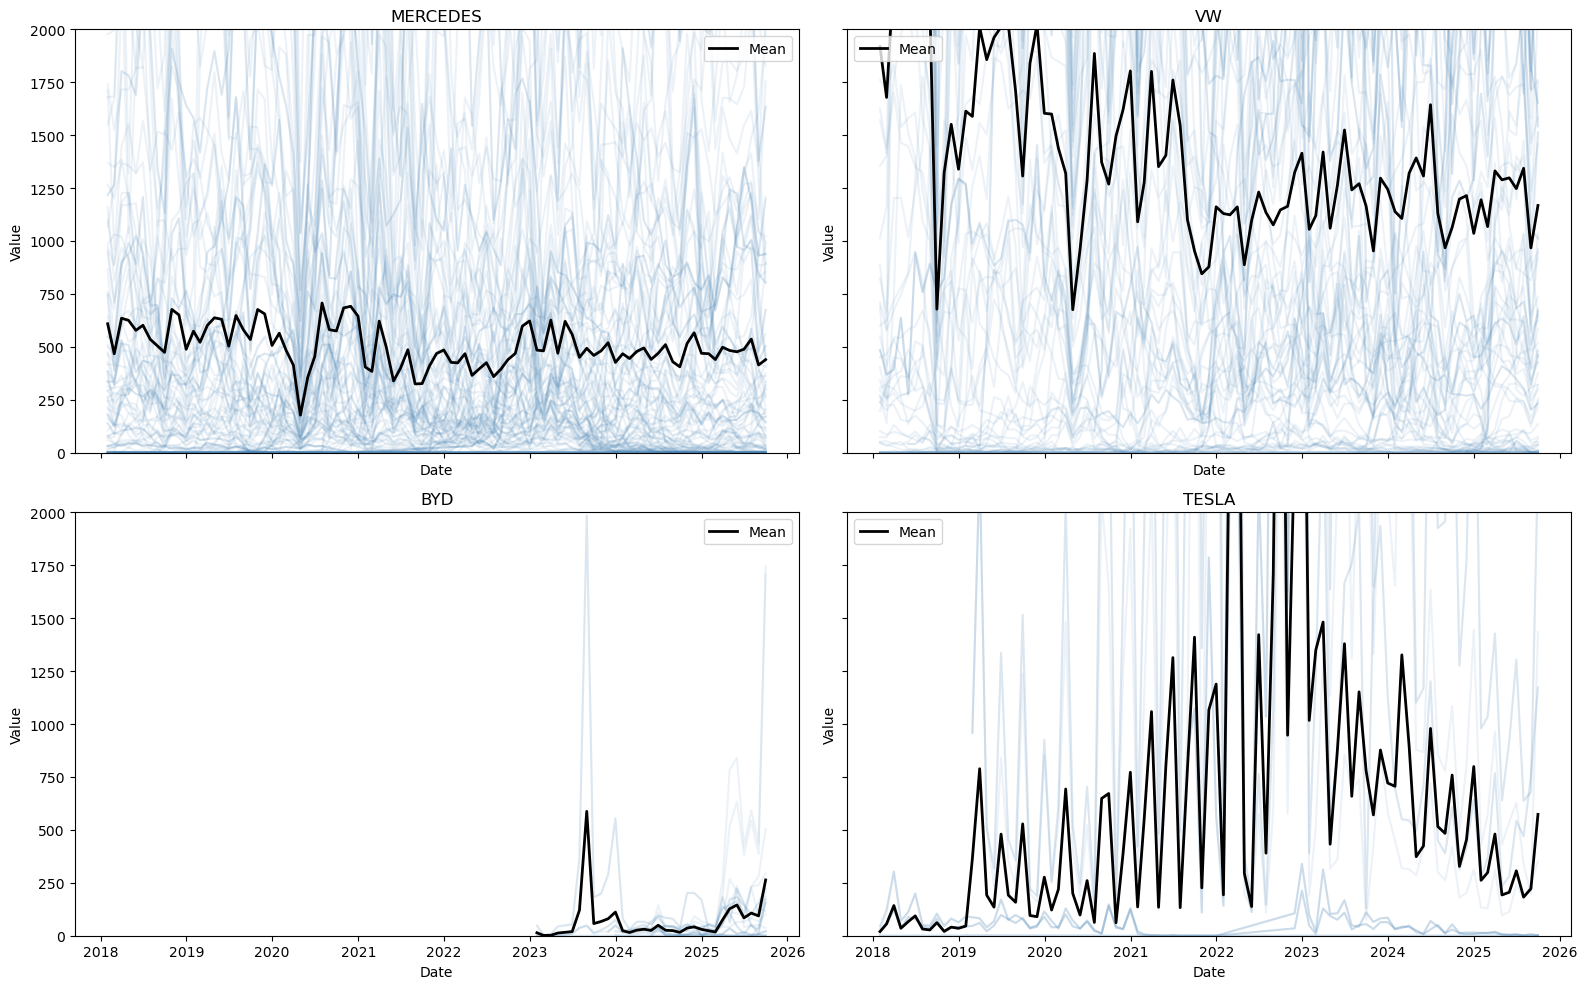

In [504]:
oems = ["MERCEDES", "VW", "BYD", "TESLA"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, v_type in zip(axes, oems):
    type_df = df[df["oem"] == v_type].copy()
    type_df = type_df.sort_values("Date")

    # Overlay aller Zeitreihen
    for _, g in type_df.groupby("ts_key"):
        ax.plot(g["Date"], g["Value"], alpha=0.1, color="steelblue")

    # Mittelwert
    mean_series = type_df.groupby("Date")["Value"].mean()
    ax.plot(mean_series.index, mean_series, color="black", linewidth=2, label="Mean")

    ax.set_title(f"{v_type}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.set_ylim(0, 2000)
    ax.legend()

plt.tight_layout()
plt.show()


When examining the registration numbers of battery electric vehicles (BEVs), random variations can be observed that cannot be attributed to trend or seasonal effects. These fluctuations are largely explained by changes in political support for this type of vehicle during specific time periods.

The overlay plot of petrol vehicle registration time series reveals a clear long-term downward trend. While individual time series exhibit substantial variability and short-term fluctuations, the aggregated mean (black line) shows a consistent decline over the observed period.

Registration numbers are relatively high in the early years (around 2018–2019), followed by a pronounced decrease starting in 2020. After this drop, the mean level remains persistently lower, with only minor short-term recoveries, indicating a structural change rather than a temporary fluctuation.

Overall, the trend suggests a sustained decline in petrol vehicle registrations over time, despite considerable heterogeneity across individual time series.*

When examining convertibles, a clear seasonality can be observed, characterized by a regular annual pattern since the beginning of the observation period.

The presence of such seasonal structures implies that machine learning models, particularly neural networks, must be capable of capturing periodic dependencies over time. This highlights the importance of incorporating sufficiently long input sequences or explicit seasonal features to enable the model to learn recurring annual patterns rather than treating them as noise.

###Autocorrelation

Autocorrelation shows how strongly current values of a time series depend on past values.
It helps identify whether the data contain meaningful temporal structure or are dominated by random noise.
Understanding autocorrelation is essential for selecting appropriate models and input sequence lengths, especially for neural networks such as LSTMs.
High autocorrelation indicates that past observations carry predictive information about future values.
Without analyzing autocorrelation, models may be poorly specified and fail to capture important temporal dependencies.

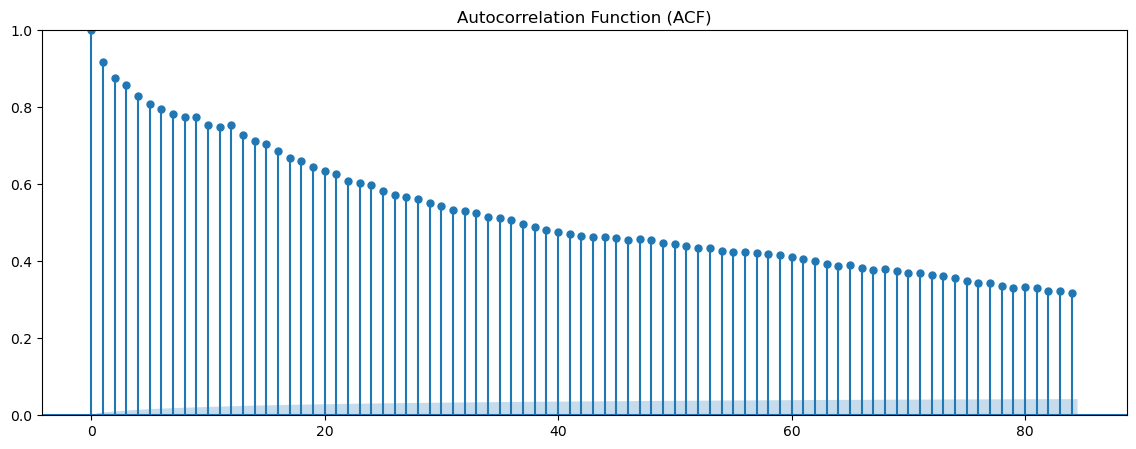

In [505]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(df["Value"], lags=84, ax=ax)

ax.set_title("Autocorrelation Function (ACF)")
ax.set_ylim(0, 1)

plt.show()

The autocorrelation function shows a strong and slowly decaying positive autocorrelation across many lags, indicating a highly persistent and non-stationary time series. The majority of autocorrelation values lie well outside the confidence interval, confirming that the temporal dependencies are statistically significant and not driven by random noise.

In addition to the average autocorrelation across all time series, category-specific autocorrelation analyses were conducted to account for structural heterogeneity between different powertrain types.

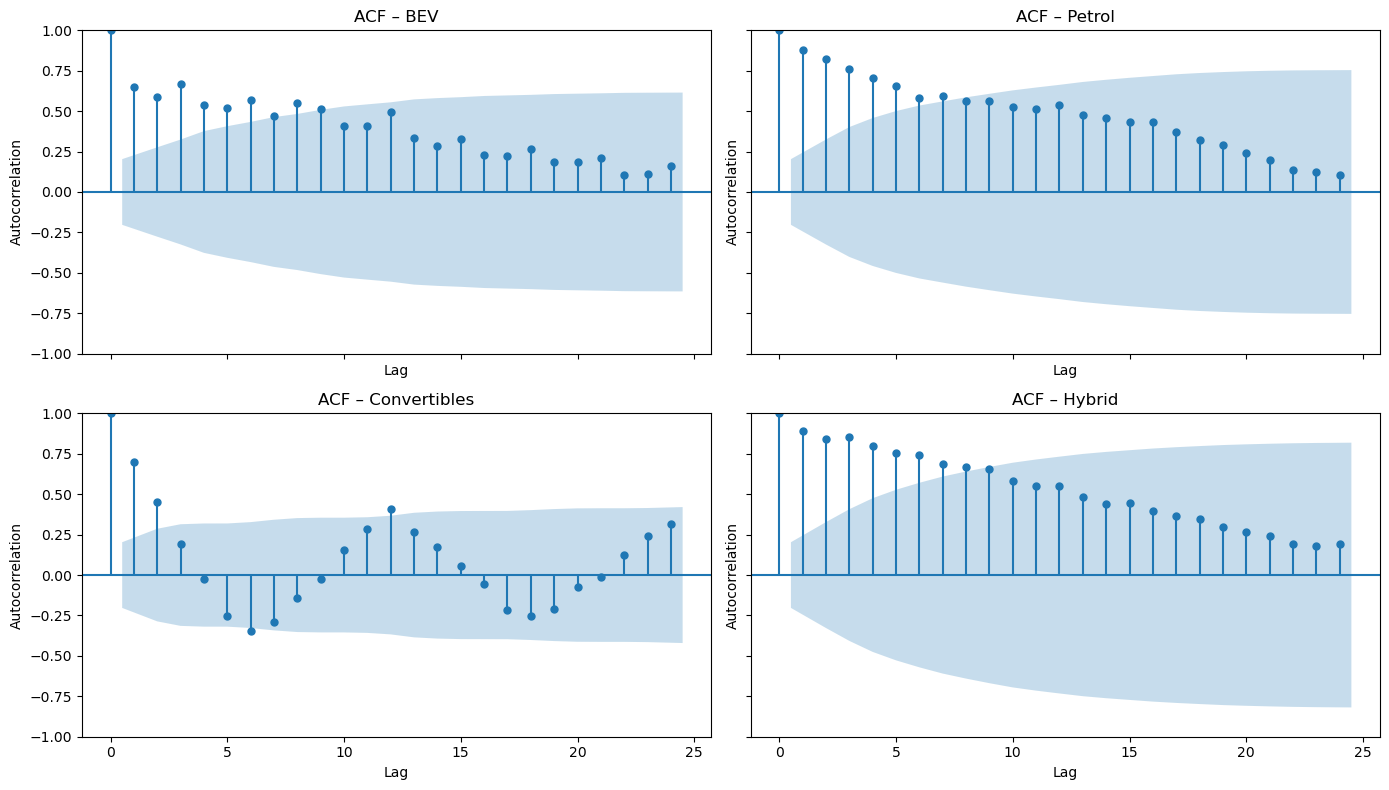

In [506]:
types = ["BEV", "Petrol", "Convertibles", "Hybrid"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, t in zip(axes, types):
    df_type = df[df["type"] == t].copy()
    df_type = df_type.sort_values("Date")

    # Aggregierte Zeitreihe (Mean pro Date)
    series = df_type.groupby("Date")["Value"].mean()
    series = series.dropna()

    plot_acf(series, lags=24, ax=ax)
    ax.set_title(f"ACF – {t}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

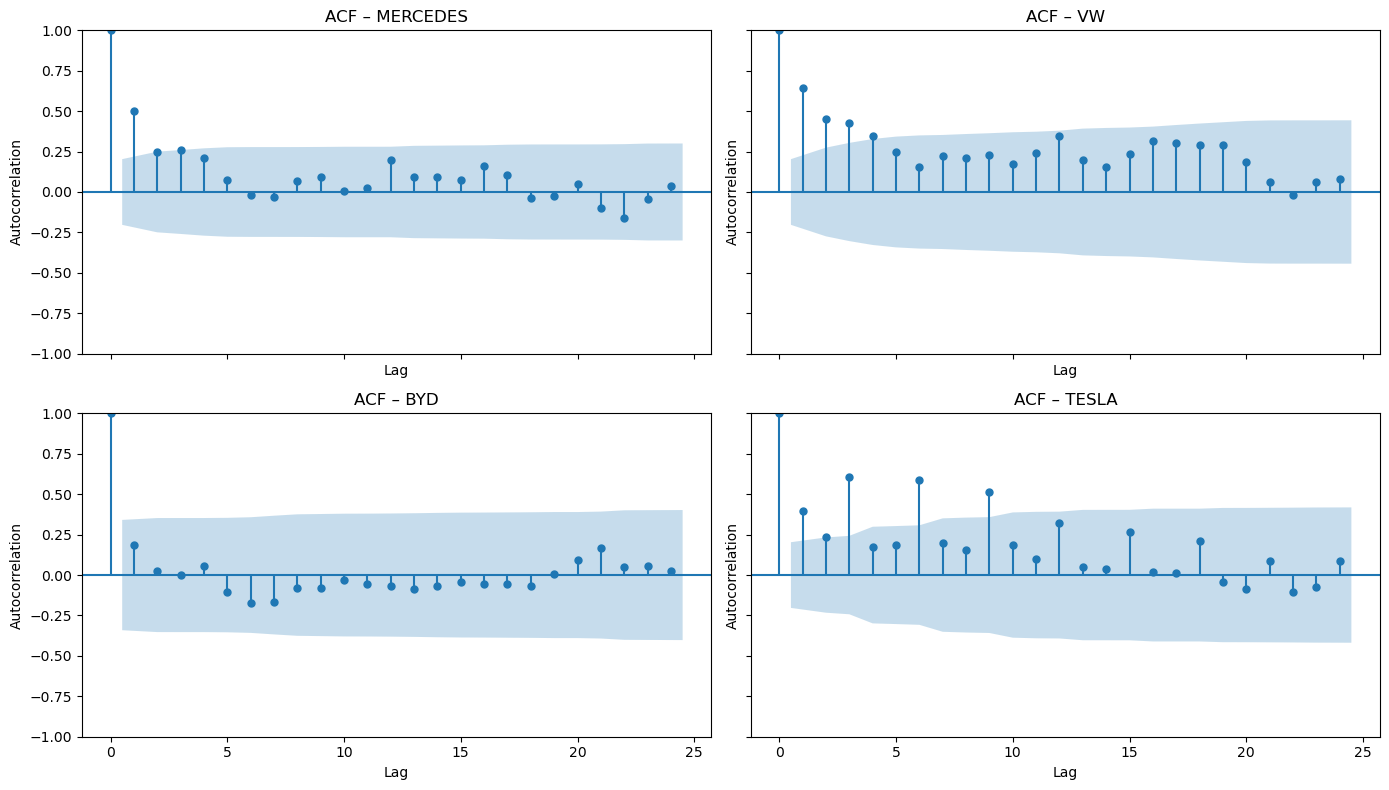

In [507]:
oems = ["MERCEDES", "VW", "BYD", "TESLA"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, oem in zip(axes, oems):
    df_oem = df[df["oem"] == oem].copy()
    df_oem = df_oem.sort_values("Date")

    # Aggregierte Zeitreihe (Mean pro Date)
    series = df_oem.groupby("Date")["Value"].mean()
    series = series.dropna()

    plot_acf(series, lags=24, ax=ax)
    ax.set_title(f"ACF – {oem}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

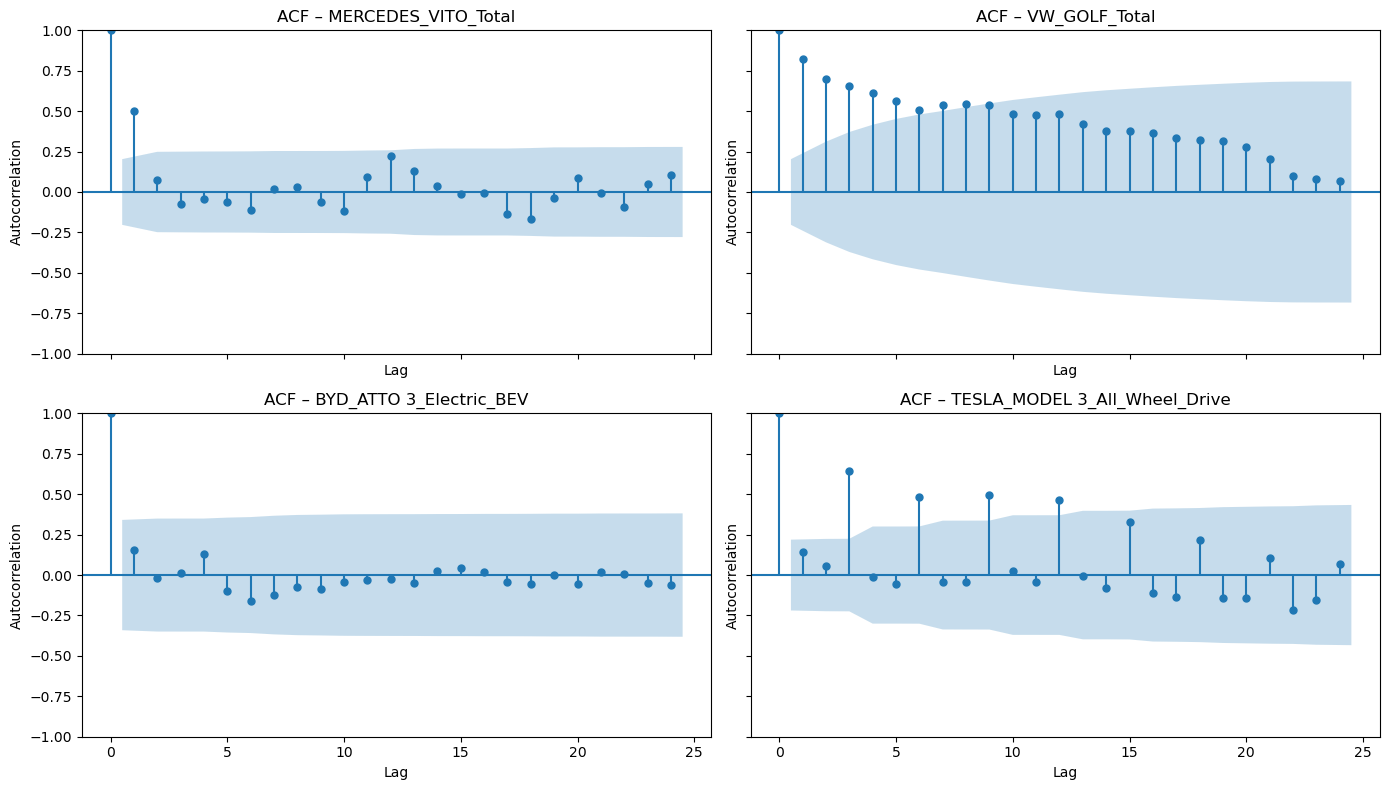

In [508]:
ts_keys = [
    "MERCEDES_VITO_Total",
    "VW_GOLF_Total",
    "BYD_ATTO 3_Electric_BEV",
    "TESLA_MODEL 3_All_Wheel_Drive"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, key in zip(axes, ts_keys):
    df_ts = df[df["ts_key"] == key].copy()
    df_ts = df_ts.sort_values("Date")

    series = df_ts["Value"].dropna()

    plot_acf(series, lags=24, ax=ax)
    ax.set_title(f"ACF – {key}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()


### Time dependent mulitvariate correlation

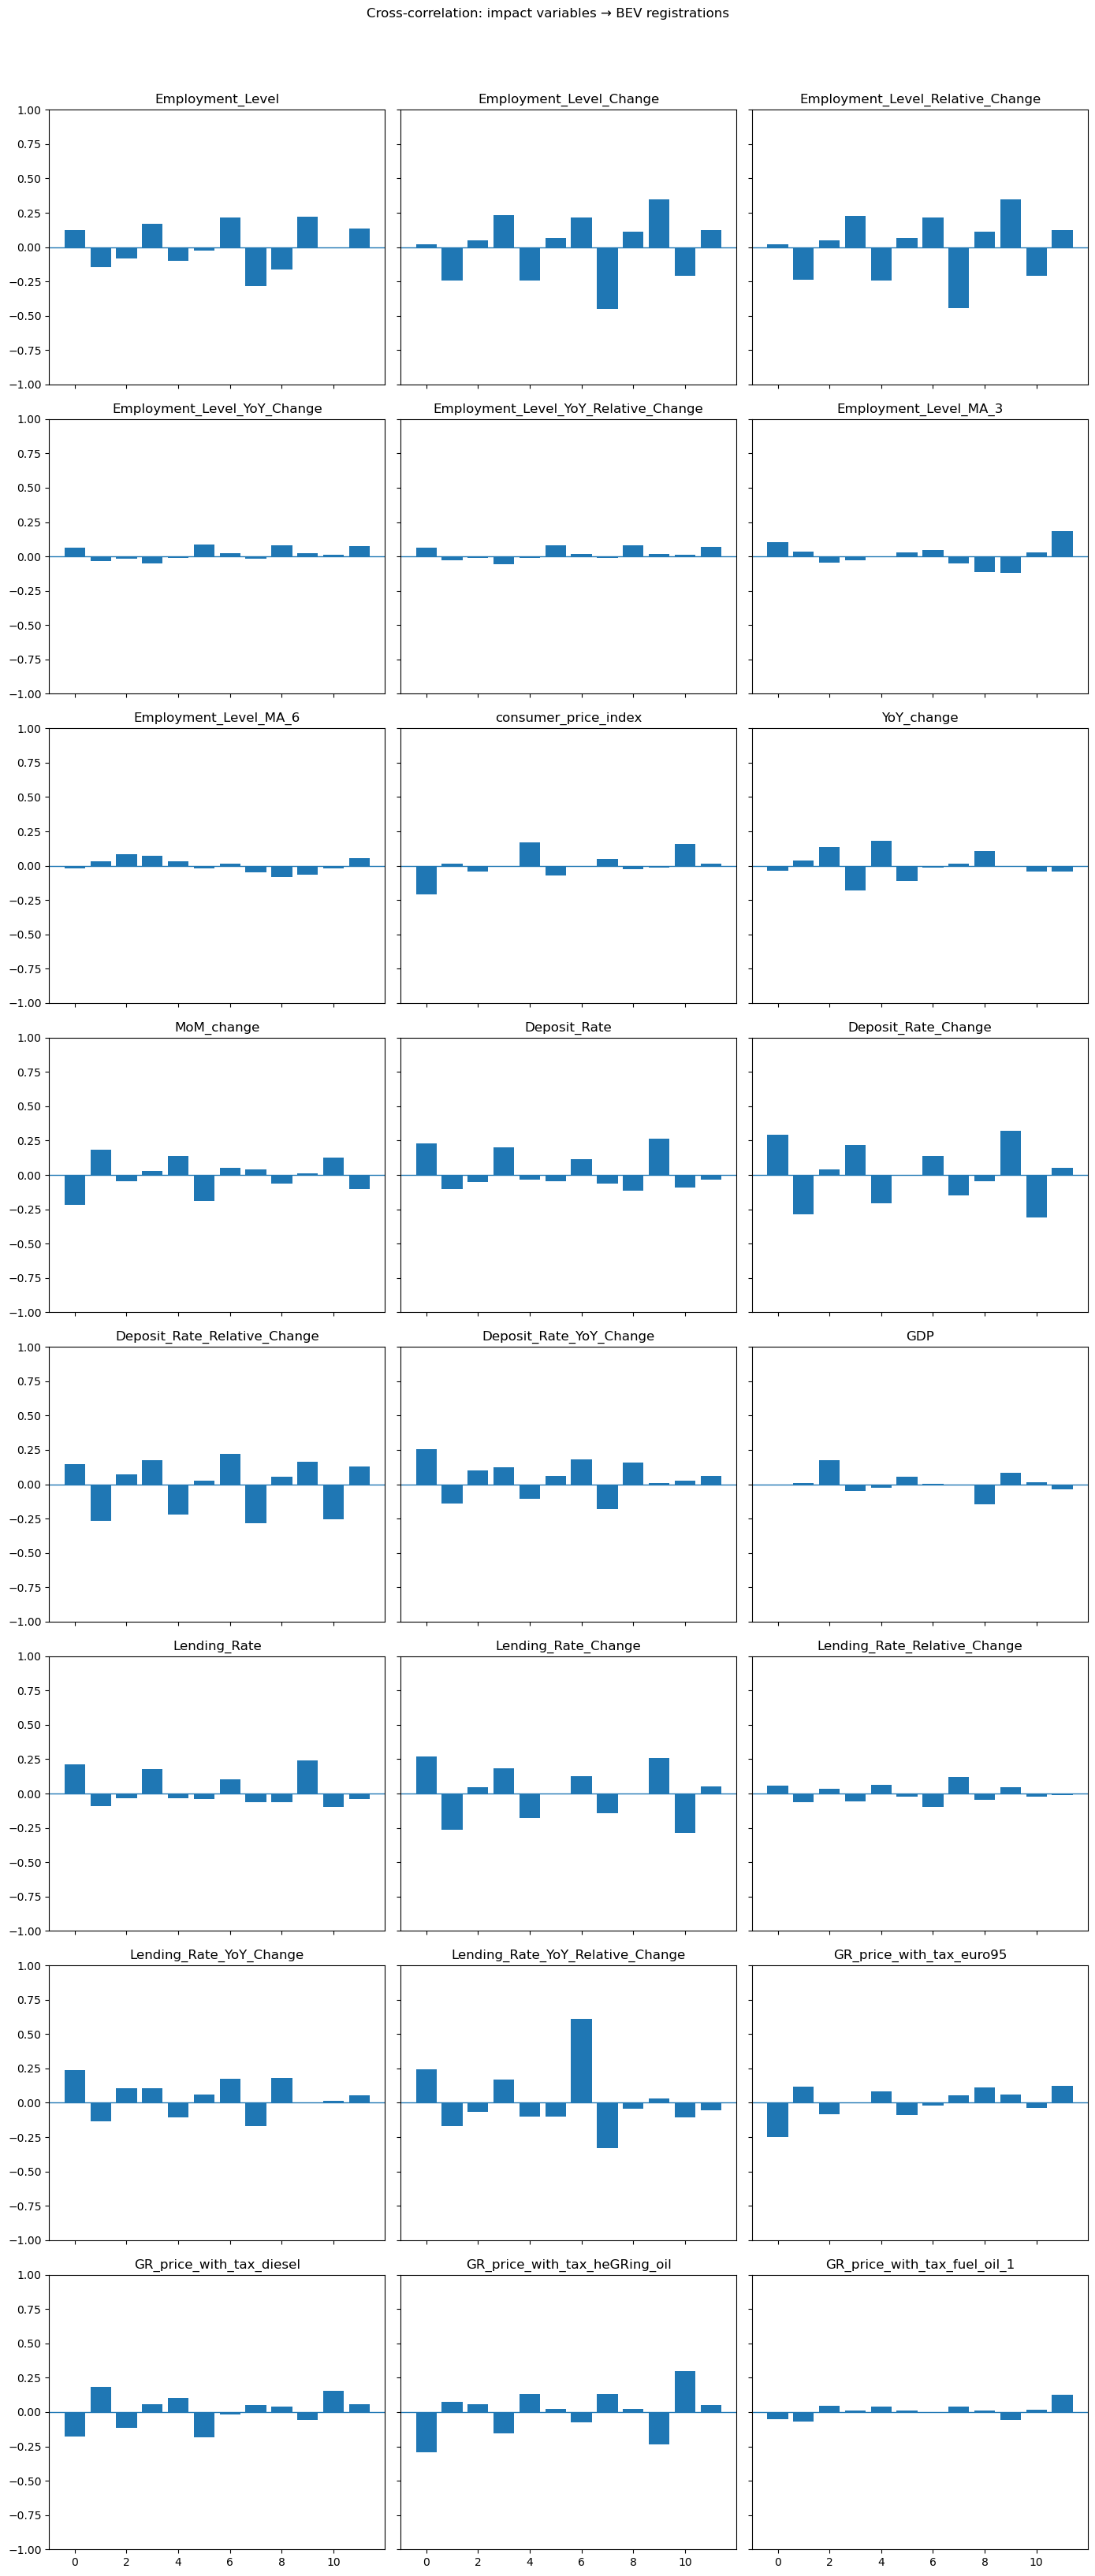

In [528]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Target series (choose type here)
target_type = "BEV"
target = df[df["type"] == target_type].groupby("Date")["Value"].mean()

# Impact columns (numeric only)
exclude = {"Date", "ts_key", "Value", "type", "oem"}
impact_cols = [c for c in df.select_dtypes("number").columns if c not in exclude]

n_cols = 3
n_rows = math.ceil(len(impact_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=True, sharey=True)
axes = np.ravel(axes)

for ax, col in zip(axes, impact_cols):
    impact = df.groupby("Date")[col].mean()
    d = pd.concat([impact, target], axis=1).dropna().diff().dropna()
    d = (d - d.mean()) / d.std()

    lags = min(12, len(d) - 1)
    if lags < 2 or d.isna().any().any():
        ax.axis("off"); continue

    cc = ccf(d.iloc[:, 0], d.iloc[:, 1])[:lags]
    ax.bar(range(lags), cc)
    ax.axhline(0, linewidth=1)
    ax.set_title(col)
    ax.set_ylim(-1, 1)

for ax in axes[len(impact_cols):]:
    ax.remove()

fig.suptitle(f"Cross-correlation: impact variables → {target_type} registrations", y=1.02)
plt.tight_layout()
plt.show()

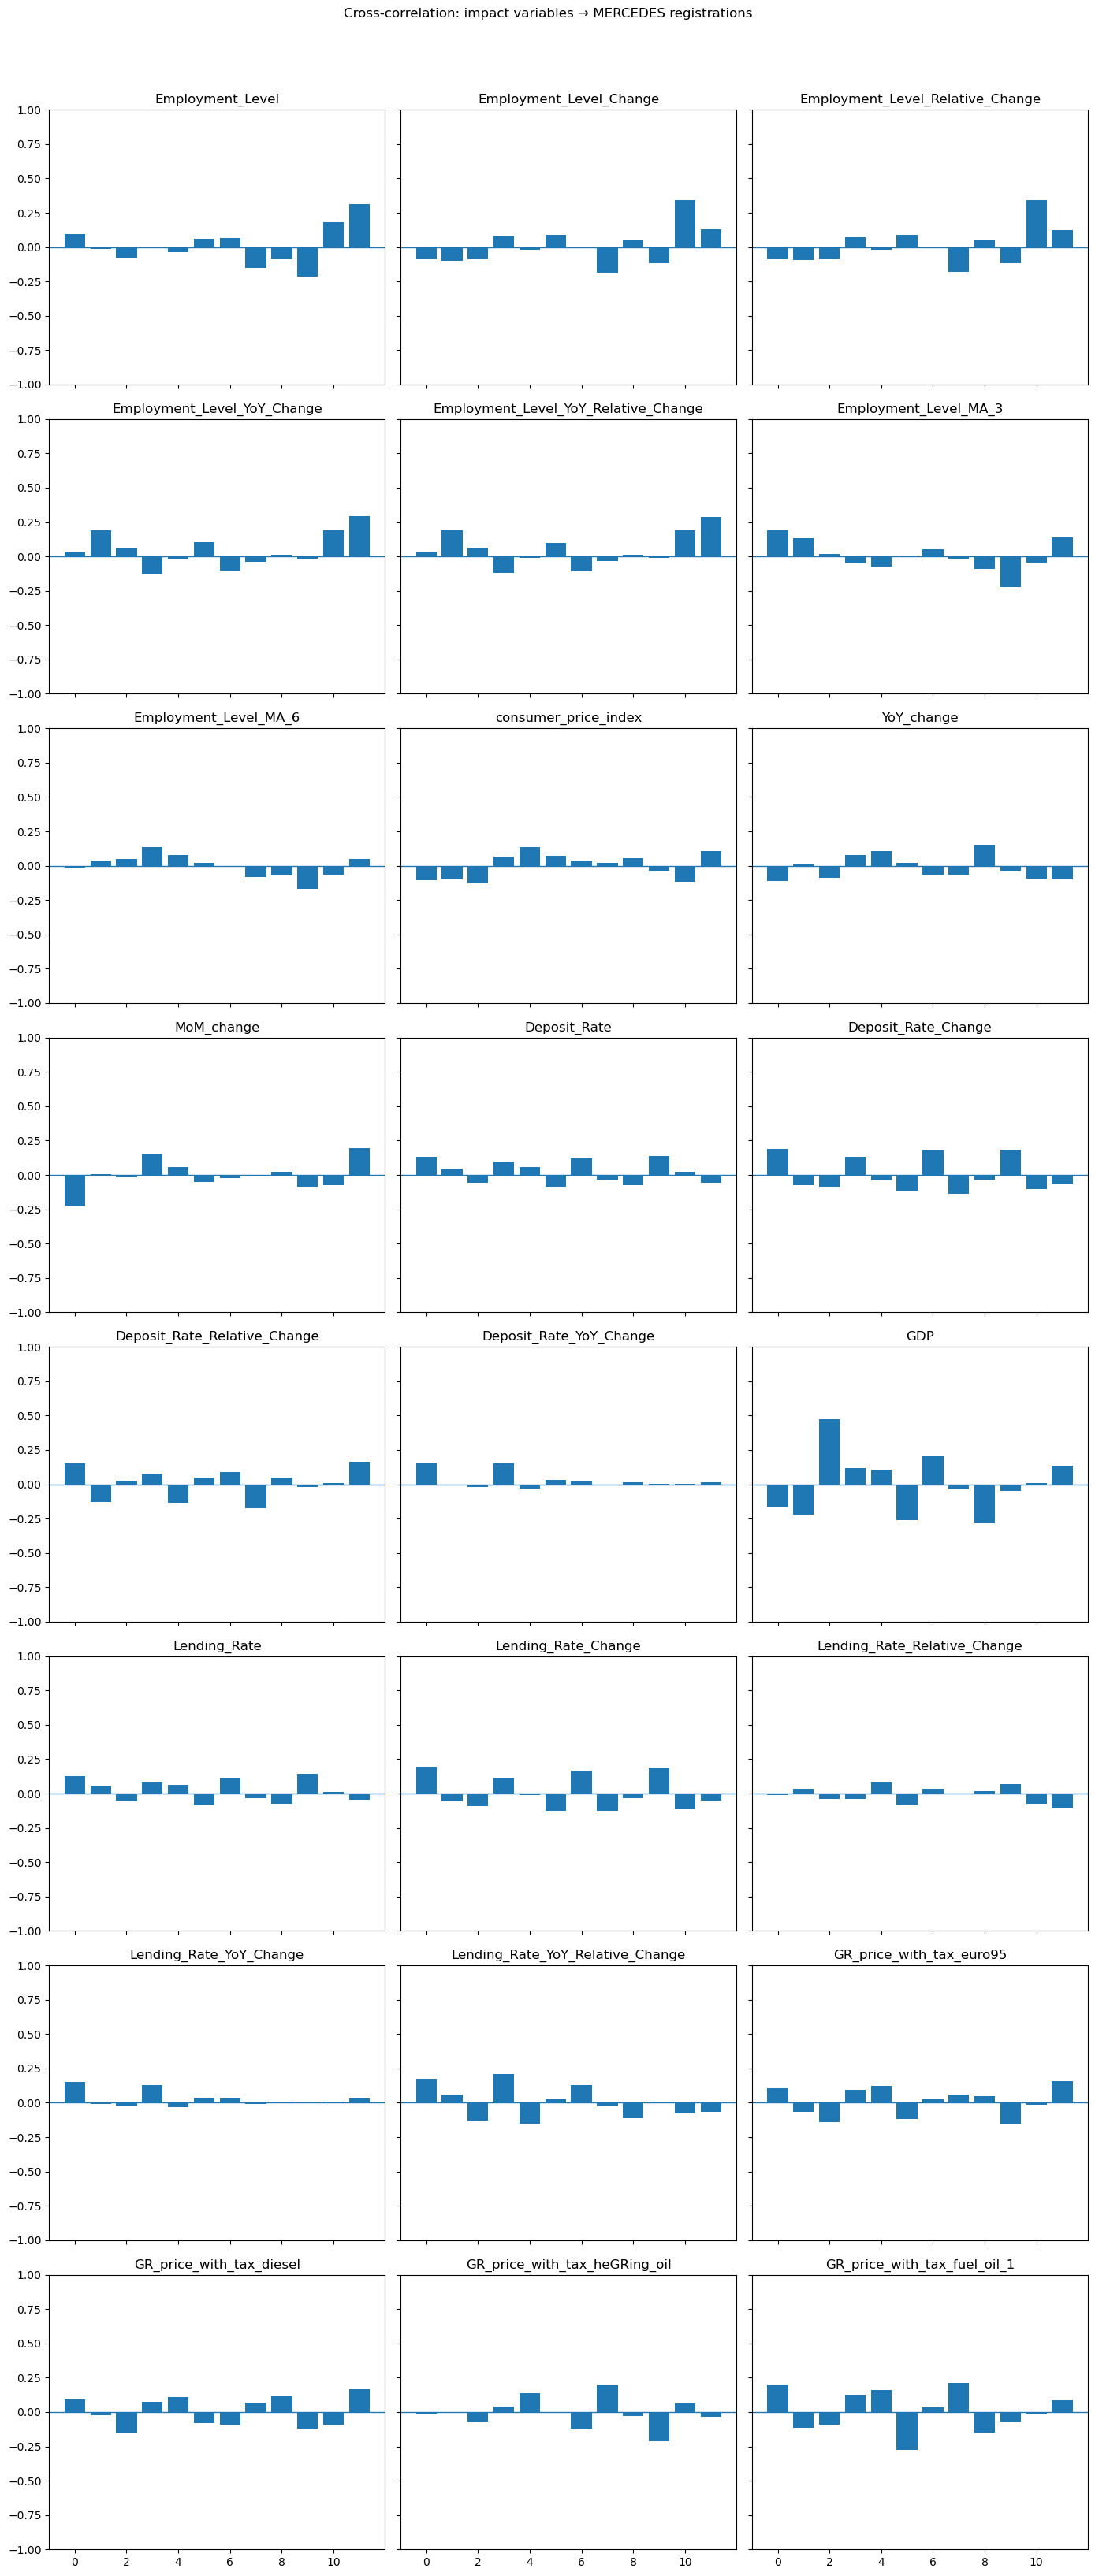

In [527]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Target series (choose type here)
target_oem = "MERCEDES"
target = df[df["oem"] == target_oem].groupby("Date")["Value"].mean()

# Impact columns (numeric only)
exclude = {"Date", "ts_key", "Value", "type", "oem"}
impact_cols = [c for c in df.select_dtypes("number").columns if c not in exclude]

n_cols = 3
n_rows = math.ceil(len(impact_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=True, sharey=True)
axes = np.ravel(axes)

for ax, col in zip(axes, impact_cols):
    impact = df.groupby("Date")[col].mean()
    d = pd.concat([impact, target], axis=1).dropna().diff().dropna()
    d = (d - d.mean()) / d.std()

    lags = min(12, len(d) - 1)
    if lags < 2 or d.isna().any().any():
        ax.axis("off"); continue

    cc = ccf(d.iloc[:, 0], d.iloc[:, 1])[:lags]
    ax.bar(range(lags), cc)
    ax.axhline(0, linewidth=1)
    ax.set_title(col)
    ax.set_ylim(-1, 1)

for ax in axes[len(impact_cols):]:
    ax.remove()

fig.suptitle(f"Cross-correlation: impact variables → {target_oem} registrations", y=1.02)
plt.tight_layout()
plt.show()

In [525]:
Tesla_list = df[df['oem']=='MERCEDES']['ts_key'].unique().tolist()
Tesla_list

['MERCEDES_A-KLASSE_Diesel',
 'MERCEDES_A-KLASSE_Hybrid',
 'MERCEDES_VITO_Hybrid',
 'MERCEDES_VITO_Total',
 'MERCEDES_VITO_Electric_BEV',
 'MERCEDES_VITO_Petrol',
 'MERCEDES_A-KLASSE_All_Wheel_Drive',
 'MERCEDES_GLK, GLC_Total',
 'MERCEDES_ML-KLASSE, GLE_All_Wheel_Drive',
 'MERCEDES_ML-KLASSE, GLE_Diesel',
 'MERCEDES_AMG GT_Total',
 'MERCEDES_B-KLASSE_All_Wheel_Drive',
 'MERCEDES_B-KLASSE_Hybrid',
 'MERCEDES_B-KLASSE_Total',
 'MERCEDES_C-KLASSE_Convertibles',
 'MERCEDES_S-KLASSE_Diesel',
 'MERCEDES_S-KLASSE_Electric_BEV',
 'MERCEDES_S-KLASSE_Hybrid',
 'MERCEDES_S-KLASSE_Petrol',
 'MERCEDES_S-KLASSE_Total',
 'MERCEDES_ML-KLASSE, GLE_Hybrid',
 'MERCEDES_ML-KLASSE, GLE_Petrol',
 'MERCEDES_ML-KLASSE, GLE_Total',
 'MERCEDES_S-KLASSE_All_Wheel_Drive',
 'MERCEDES_GLK, GLC_Petrol',
 'MERCEDES_GLK, GLC_Hybrid',
 'MERCEDES_SL_All_Wheel_Drive',
 'MERCEDES_AMG GT_Petrol',
 'MERCEDES_CITAN_Petrol',
 'MERCEDES_B-KLASSE_Diesel',
 'MERCEDES_B-KLASSE_Petrol',
 'MERCEDES_C-KLASSE_All_Wheel_Drive',
 'MER

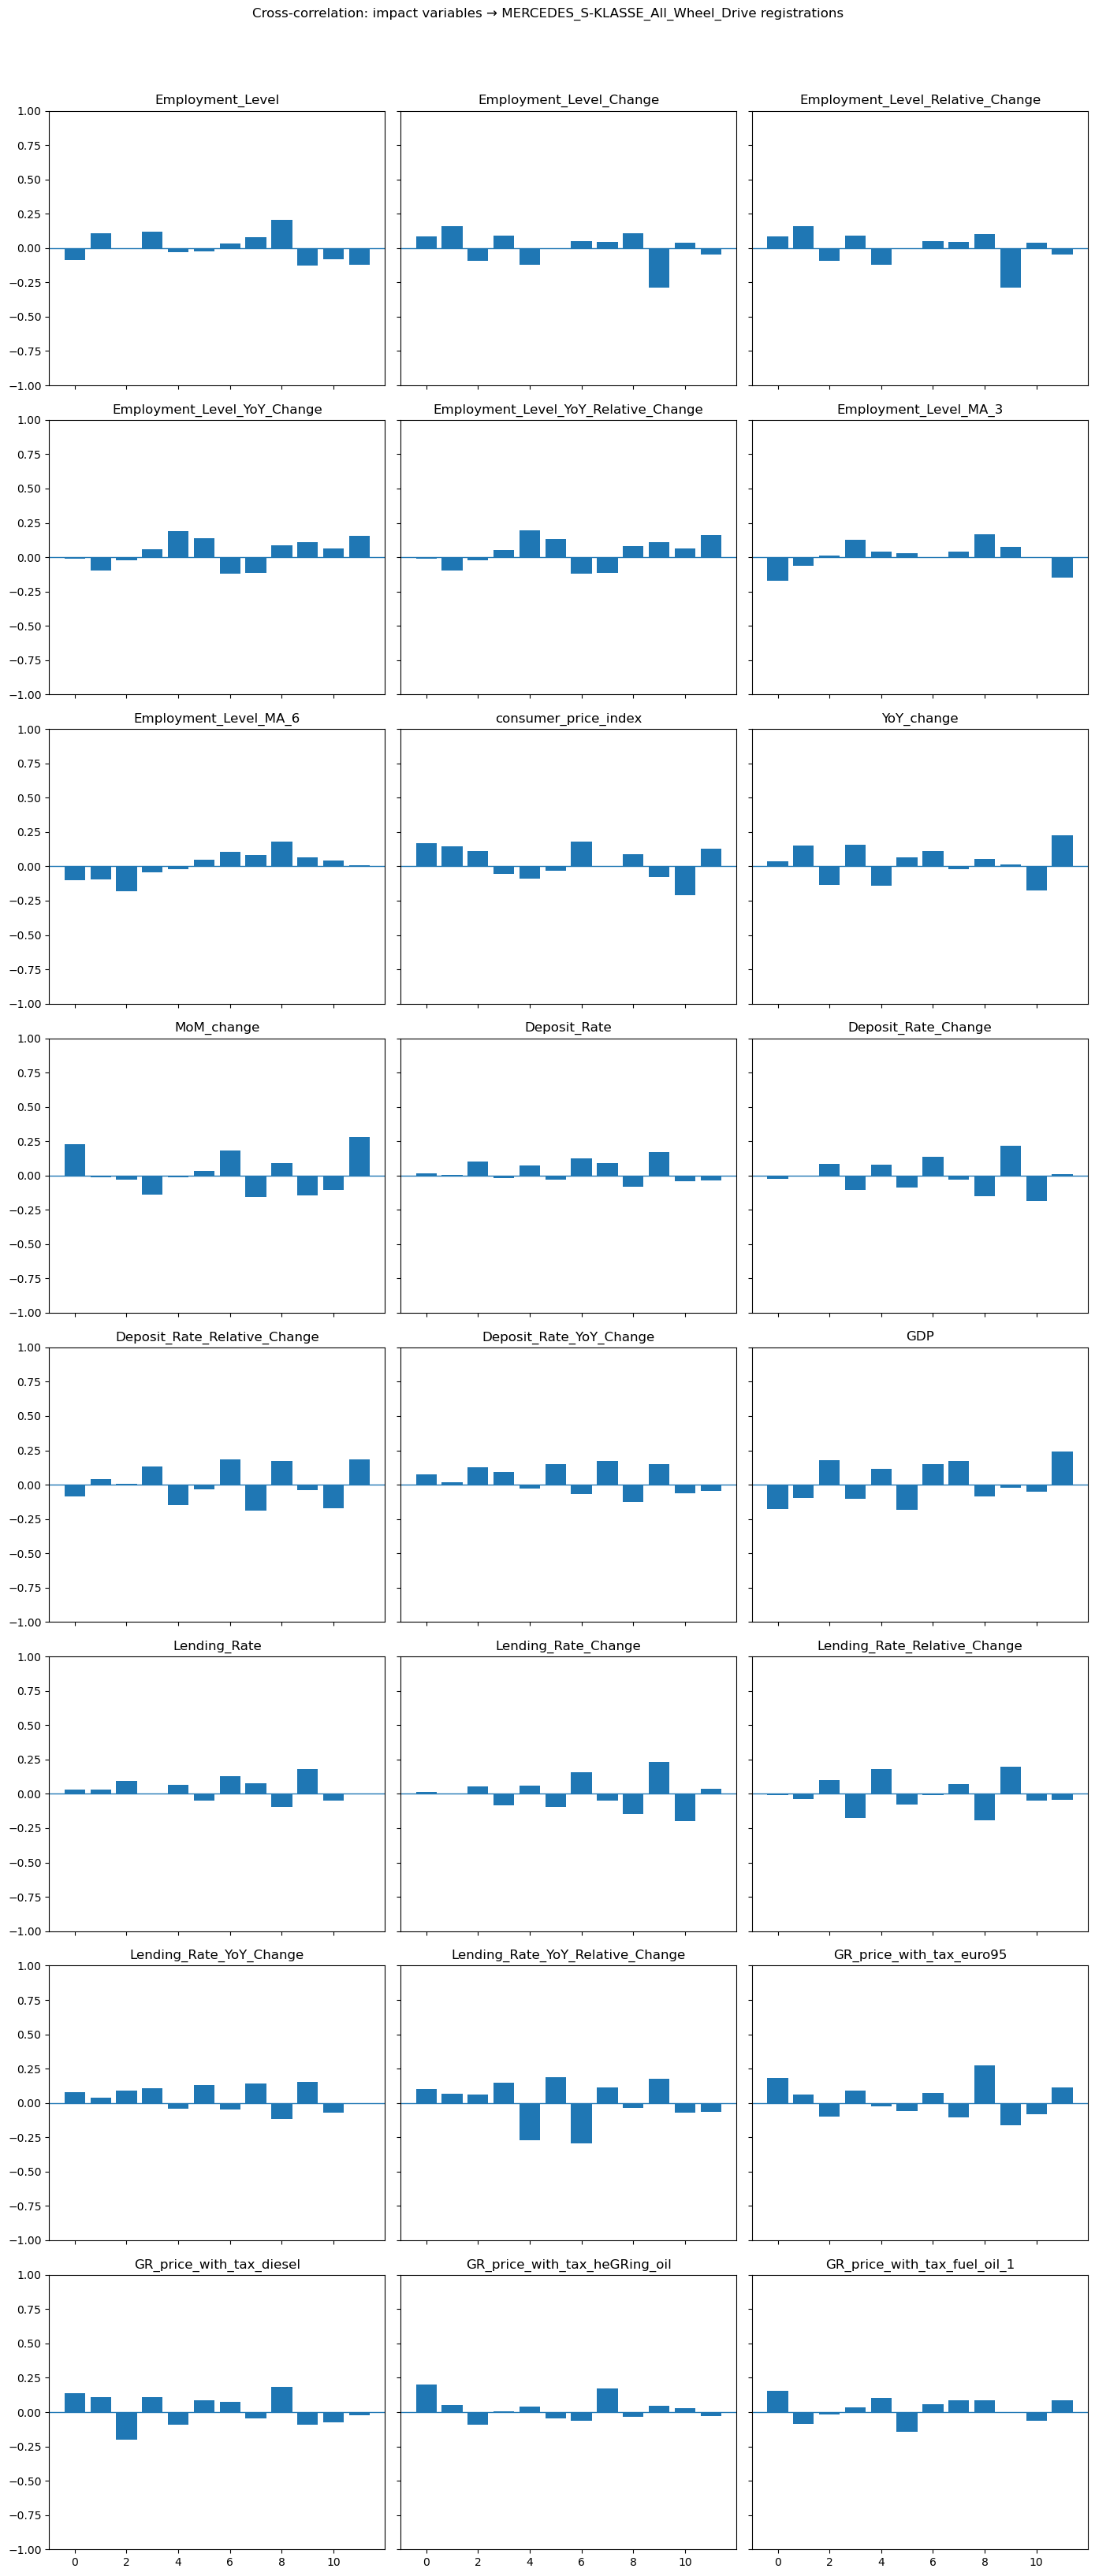

In [529]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Target series (choose type here)
target_model = "MERCEDES_S-KLASSE_All_Wheel_Drive"
target = df[df["ts_key"] == target_model].groupby("Date")["Value"].mean()

# Impact columns (numeric only)
exclude = {"Date", "ts_key", "Value", "type", "oem"}
impact_cols = [c for c in df.select_dtypes("number").columns if c not in exclude]

n_cols = 3
n_rows = math.ceil(len(impact_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=True, sharey=True)
axes = np.ravel(axes)

for ax, col in zip(axes, impact_cols):
    impact = df.groupby("Date")[col].mean()
    d = pd.concat([impact, target], axis=1).dropna().diff().dropna()
    d = (d - d.mean()) / d.std()

    lags = min(12, len(d) - 1)
    if lags < 2 or d.isna().any().any():
        ax.axis("off"); continue

    cc = ccf(d.iloc[:, 0], d.iloc[:, 1])[:lags]
    ax.bar(range(lags), cc)
    ax.axhline(0, linewidth=1)
    ax.set_title(col)
    ax.set_ylim(-1, 1)

for ax in axes[len(impact_cols):]:
    ax.remove()

fig.suptitle(f"Cross-correlation: impact variables → {target_model} registrations", y=1.02)
plt.tight_layout()
plt.show()